In [1]:
# !pip install faiss-cpu
from langchain_core.output_parsers import JsonOutputParser

In [2]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from langchain_core.language_models.chat_models import BaseChatModel
from langchain_core.vectorstores import VectorStore
from langchain_aws import ChatBedrockConverse, BedrockEmbeddings
from langchain_community.vectorstores import FAISS
import faiss
from langchain_core.prompts import PromptTemplate

from generation_agent import generate_node
from reflection_agent import reflection_node
from retrieval_agent import retrieval_node

In [3]:
class RAGState(TypedDict):
    llm: BaseChatModel    # llm from langchian BaseChatModel
    db: VectorStore
    query: str    # user query
    content: str    # content from vector db
    response: str    # llm final response
    reviewed_response: dict    # after reflection agent

In [4]:
graph = StateGraph(RAGState)

graph.add_node("retrive", retrieval_node)
graph.add_node("generate", generate_node)
graph.add_node("reflection", reflection_node)

graph.set_entry_point("retrive")
graph.add_edge("retrive", "generate")
graph.add_edge("generate", "reflection")
graph.set_finish_point("reflection")

app = graph.compile()

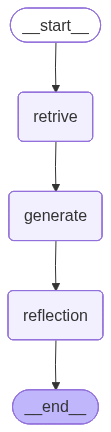

In [5]:
app

In [6]:
llm = ChatBedrockConverse(
    model_id = "amazon.nova-lite-v1:0",
    region_name = "us-east-1"
)

embed = BedrockEmbeddings(model_id="cohere.embed-english-v3")

In [7]:
db = FAISS.load_local("../../docDB/", embeddings=embed, allow_dangerous_deserialization=True)

In [8]:
retriver = db.as_retriever(search_type="similarity_score_threshold",search_kwargs={"score_threshold": 0.8})

In [9]:
query = "what is the total amount i should pay to BlueOcean Transport Co."

In [10]:
# res = db.similarity_search("what are the docyuments that are present in the database", k = 3)

In [11]:
res = app.invoke({"query" : query, "llm": llm, "db":db})

content='```json\n{\n  "confidence_score": 1.0,\n  "groundness_score": 1.0,\n  "content_relevence": 1.0\n}\n```' additional_kwargs={} response_metadata={'ResponseMetadata': {'RequestId': '91167559-2b45-4488-9f27-a5daa68881b2', 'HTTPStatusCode': 200, 'HTTPHeaders': {'date': 'Tue, 30 Dec 2025 11:39:08 GMT', 'content-type': 'application/json', 'content-length': '314', 'connection': 'keep-alive', 'x-amzn-requestid': '91167559-2b45-4488-9f27-a5daa68881b2'}, 'RetryAttempts': 0}, 'stopReason': 'end_turn', 'metrics': {'latencyMs': [351]}, 'model_name': 'amazon.nova-lite-v1:0'} id='lc_run--019b6f0e-0250-72c3-80b3-121905c15c67-0' usage_metadata={'input_tokens': 2486, 'output_tokens': 43, 'total_tokens': 2529, 'input_token_details': {'cache_creation': 0, 'cache_read': 0}}


In [22]:
print(res["reviewed_response"])

{'confidence_score': 1.0, 'groundness_score': 1.0, 'content_relevence': 1.0}


In [34]:
def json_to_markdown(json_data):
    # Initialize the markdown string
    markdown = "# JSON Data Summary\n\n"
    
    # Loop through each key-value pair in the JSON data
    for key, value in json_data.items():
        markdown += f"##### {key.replace('_', ' ').title()}\n"
        markdown += f"Value: {value}\n\n"
    
    return markdown

In [33]:
print(json_to_markdown(res["reviewed_response"]))

# JSON Data Summary

## Confidence Score
Value: 1.0

## Groundness Score
Value: 1.0

## Content Relevence
Value: 1.0




#### Confidence Score
Value: 1.0

#### Groundness Score
Value: 1.0

#### Content Relevence
Value: 1.0

In [43]:
res["response"]

'The total amount you should pay to BlueOcean Transport Co. is $275.00.'

In [14]:
from langchain_core.prompts import PromptTemplate

In [15]:
template = """
    You are an helpful ai assistant, your goal is to find the confidence score, groundness score and content relevence score for the given query and content with the answer

    use the bellow information to generate the scores and give the scores in between 0 and 1
 ## query : {query}
 ## content :{content}
 ## response:{response}

strictly return the output in json format and follow the bellow output template
{{
"confidence_score" : 0 to 1,
"groundness_score" : 0 to 1,
"content_relevence" : 0 to 1
}}
 """
prompt = PromptTemplate.from_template(template= template)

In [16]:
prompt

PromptTemplate(input_variables=['content', 'query', 'response'], input_types={}, partial_variables={}, template='\n    You are an helpful ai assistant, your goal is to find the confidence score, groundness score and content relevence score for the given query and content with the answer\n\n    use the bellow information to generate the scores and give the scores in between 0 and 1\n ## query : {query}\n ## content :{content}\n ## response:{response}\n\nstrictly return the output in json format and follow the bellow output template\n{{\n"confidence_score" : 0 to 1,\n"groundness_score" : 0 to 1,\n"content_relevence" : 0 to 1\n}}\n ')

In [17]:
files = db.similarity_search("give me the iformation about 6524 invoice", k = 10)

In [18]:
len(files)

4

In [42]:
files[3]

Document(id='79cb1bc5-b0e1-424e-bd72-a5160d0004c0', metadata={}, page_content="{'header': {'invoice_no': 'RE-2025-004', 'invoice_date': '02.05.2025', 'vendor_id': 'HafenLogistik GmbH', 'currency': '€', 'po_reference': 'PO-1004', 'total_amount': '1760.00€'}, 'line_item': [{'item_code': 'SKU-301', 'description': 'Transport Crates', 'qty': 40, 'unit_price': '25.00€', 'total': '1000.00€'}, {'item_code': 'SKU-302', 'description': 'Safety Vests', 'qty': 60, 'unit_price': '10.00€', 'total': '600.00€'}], 'confidence': 1.0, 'missing': [], 'discrepancy_report': {}, 'file_name': 'INV_DE_004', 'sender': 'rechnung@hafenlogistik.de', 'subject': 'Rechnung RE-2025-004 - Bestellung PO-1004', 'received_timestamp': '2025-05-02T11:00:00Z', 'language': 'de', 'attachments': ['INV_DE_004.docx'], 'recommendation': 'Approve', 'status': 'Not Required', 'remarks': 'Not Required'}")

In [29]:
for file in files:
    _data = file.page_content.split(":")
    index = -1
    for i in _data:
        if "file_name" in i:
            index = _data.index(i)

    print(_data[index+1])

 'INV_EN_005_scan', 'sender'
 'INV_EN_006_malformed', 'sender'
 'INV_EN_002', 'sender'
 'INV_DE_004', 'sender'


In [30]:
files[1]

Document(id='fba0c2f8-69c0-4ee7-9587-4b8cfe47bf7f', metadata={}, page_content="{'header': {'invoice_no': 'PO-1006', 'invoice_date': '1 June 2025', 'vendor_id': 'OceanFreight Pvt Ltd', 'currency': 'Not specified', 'po_reference': 'PO-1006', 'total_amount': 44000}, 'line_item': [{'item_code': 'SKU-501', 'description': 'Container Transport', 'qty': 5, 'unit_price': 8000, 'total': 40000}], 'confidence': 1.0, 'missing': ['currency'], 'discrepancy_report': {'invoice_validation_report': {'header_validation': {'invoice_number': 'PO-1006', 'vendor_id': 'OceanFreight Pvt Ltd', 'vendor_currency': 'INR', 'po_reference': 'PO-1006', 'total_amount': {'invoice_total': 44000, 'db_total': None, 'difference': None, 'difference_percent': None}, 'discrepancy_flag': False}, 'line_item_validation': [{'item_code': 'SKU-501', 'description': 'Container Transport', 'quantity': {'invoice_qty': 5, 'db_qty': 5, 'difference': 0, 'difference_percent': 0}, 'unit_price': {'invoice_price': 8000, 'db_price': 8000.0, 'dif